# D1 — Know Your Data
## Adult Income Dataset (UCI Census Income)

**Author:** Emanuel  
**Course:** IS — Machine Learning  
**Date:** 2026

---

### Notebook Overview

1. Dataset Acquisition
2. Data Reading
3. Data Cleaning
4. Data Preparation
5. EDA — Exploratory Data Analysis
6. Export for D2
7. Conclusions

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

FIG_DIR = 'figures_D1'
os.makedirs(FIG_DIR, exist_ok=True)
print(f'Figures will be saved to: {FIG_DIR}/')
print('Libraries loaded.')

Figures will be saved to: figures_D1/
Libraries loaded.


---
## 1. Dataset Acquisition

The **Adult Income** dataset (also known as *Census Income*) was extracted from the 1994 US Census database by Barry Becker and donated to the UCI Machine Learning Repository.

**Source:** [UCI ML Repository — Adult](https://archive.ics.uci.edu/ml/datasets/adult)

**Reference:**  
Kohavi, R. (1996). *Scaling Up the Accuracy of Naive-Bayes Classifiers: A Decision-Tree Hybrid.* Proceedings of the Second International Conference on Knowledge Discovery and Data Mining (KDD '96).

### Features

| Feature | Type | Description |
|---|---|---|
| age | Numerical | Age of the individual |
| workclass | Categorical | Type of employer |
| fnlwgt | Numerical | Census sampling weight |
| education | Categorical | Highest education level |
| education-num | Numerical | Education level as a number |
| marital-status | Categorical | Marital status |
| occupation | Categorical | Type of job |
| relationship | Categorical | Role in household |
| race | Categorical | Race |
| sex | Categorical | Gender |
| capital-gain | Numerical | Capital gains |
| capital-loss | Numerical | Capital losses |
| hours-per-week | Numerical | Hours worked per week |
| native-country | Categorical | Country of origin |
| income | Categorical (Target) | <=50K or >50K |

### Prediction Targets (used in D2)
- **Classification:** `income_binary` — 1 if income >50K, 0 otherwise
- **Regression:** `hours-per-week` — continuous target, number of hours worked per week

In [2]:
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
df = pd.read_csv(url, names=column_names, sep=',', skipinitialspace=True, na_values='?')

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset loaded: 32561 rows, 15 columns


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


---
## 2. Data Reading

In [3]:
print(f'Shape: {df.shape}')
print(f'\nData types:')
print(df.dtypes)

Shape: (32561, 15)

Data types:
age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object


In [4]:
print('Numerical statistics:')
df.describe().round(3)

Numerical statistics:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000,32561.000,32561.000,32561.000,32561.000,32561.000
mean,38.582,189778.367,10.081,1077.649,87.304,40.437
std,13.640,105549.978,2.573,7385.292,402.960,12.347
min,17.000,12285.000,1.000,0.000,0.000,1.000
25%,28.000,117827.000,9.000,0.000,0.000,40.000
50%,37.000,178356.000,10.000,0.000,0.000,40.000
75%,48.000,237051.000,12.000,0.000,0.000,45.000
max,90.000,1484705.000,16.000,99999.000,4356.000,99.000


In [5]:
print('Categorical columns — unique values:')
for col in df.select_dtypes(include='object').columns:
    unique_vals = list(df[col].dropna().unique())
    chunks = [unique_vals[i:i + 10] for i in range(0, len(unique_vals), 10)]
    formatted = '\n    '.join([', '.join(chunk) for chunk in chunks])
    print(f' {col}: {df[col].nunique()} unique -> \n   {formatted}\n')

Categorical columns — unique values:
 workclass: 8 unique -> 
   State-gov, Self-emp-not-inc, Private, Federal-gov, Local-gov, Self-emp-inc, Without-pay, Never-worked

 education: 16 unique -> 
   Bachelors, HS-grad, 11th, Masters, 9th, Some-college, Assoc-acdm, Assoc-voc, 7th-8th, Doctorate
    Prof-school, 5th-6th, 10th, 1st-4th, Preschool, 12th

 marital-status: 7 unique -> 
   Never-married, Married-civ-spouse, Divorced, Married-spouse-absent, Separated, Married-AF-spouse, Widowed

 occupation: 14 unique -> 
   Adm-clerical, Exec-managerial, Handlers-cleaners, Prof-specialty, Other-service, Sales, Craft-repair, Transport-moving, Farming-fishing, Machine-op-inspct
    Tech-support, Protective-serv, Armed-Forces, Priv-house-serv

 relationship: 6 unique -> 
   Not-in-family, Husband, Wife, Own-child, Unmarried, Other-relative

 race: 5 unique -> 
   White, Black, Asian-Pac-Islander, Amer-Indian-Eskimo, Other

 sex: 2 unique -> 
   Male, Female

 native-country: 41 unique -> 
   Unite

---
## 3. Data Cleaning

Missing values per column:
                Count   Percent
occupation       1843  5.660146
workclass        1836  5.638647
native-country    583  1.790486


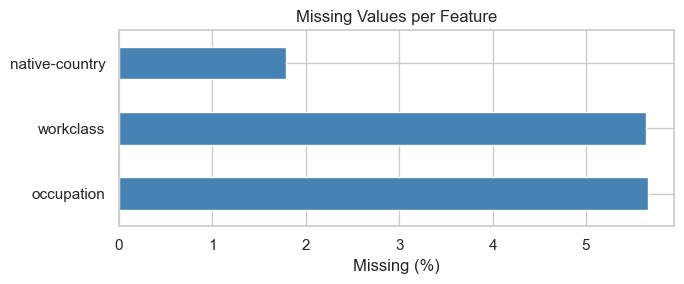

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0].sort_values('Percent', ascending=False)

print('Missing values per column:')
print(missing_df)

fig, ax = plt.subplots(figsize=(7, 3))
missing_df['Percent'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values per Feature')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_missing_values.png', bbox_inches='tight')
plt.show()

In [7]:
before = len(df)
df = df.drop_duplicates()
print(f'Duplicates removed: {before - len(df)} rows  |  Dataset size: {len(df)}')

Duplicates removed: 24 rows  |  Dataset size: 32537


In [8]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

df['income'] = df['income'].str.replace('.', '', regex=False)
print(f'Income values after cleaning: {df["income"].unique()}')

Income values after cleaning: <StringArray>
['<=50K', '>50K']
Length: 2, dtype: str


In [9]:
# --- Impute missing values with mode ---
for col in ['workclass', 'occupation', 'native-country']:
    mode_val = df[col].mode()[0]
    n = df[col].isnull().sum()
    df[col] = df[col].fillna(mode_val)
    print(f'  {col}: {n} missing values filled with mode "{mode_val}"')

print(f'\nMissing values remaining: {df.isnull().sum().sum()}')

  workclass: 1836 missing values filled with mode "Private"
  occupation: 1843 missing values filled with mode "Prof-specialty"
  native-country: 582 missing values filled with mode "United-States"

Missing values remaining: 0


---
## 4. Data Preparation

In [10]:
df_processed = df.copy()

# Binary target encoding
df_processed['income_binary'] = (df_processed['income'] == '>50K').astype(int)
print('Target encoded: income_binary (0 = <=50K, 1 = >50K)')

Target encoded: income_binary (0 = <=50K, 1 = >50K)


In [11]:
# --- Feature engineering ---
# capital_net: net capital activity (gain minus loss)
df_processed['capital_net'] = df_processed['capital-gain'] - df_processed['capital-loss']

# married: binary flag 
df_processed['married'] = df_processed['marital-status'].apply(
    lambda x: 1 if 'Married' in str(x) else 0
)

# full_time: binary flag for working 40+ hours per week
df_processed['full_time'] = (df_processed['hours-per-week'] >= 40).astype(int)

print('Feature engineering complete: capital_net, married, full_time')

Feature engineering complete: capital_net, married, full_time


In [12]:
# --- Encoding ---
# Label encode sex (binary)
le = LabelEncoder()
df_processed['sex_enc'] = le.fit_transform(df_processed['sex'])

# One-hot encode nominal categorical features
ohe_cols = ['workclass', 'education', 'marital-status', 'occupation',
            'relationship', 'race', 'native-country']
df_processed = pd.get_dummies(df_processed, columns=ohe_cols, drop_first=True)

# Drop columns no longer needed
df_processed.drop(columns=['income', 'sex', 'fnlwgt'], inplace=True)

print(f'Encoding complete.')
print(f'Final shape: {df_processed.shape}')
df_processed.head(3)

Encoding complete.
Final shape: (32537, 100)


,age,education-num,capital-gain,capital-loss,hours-per-week,income_binary,capital_net,married,full_time,sex_enc,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,education_11th,education_12th,education_1st-4th,education_5th-6th,education_7th-8th,education_9th,education_Assoc-acdm,education_Assoc-voc,education_Bachelors,education_Doctorate,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,marital-status_Married-AF-spouse,marital-status_Married-civ-spouse,marital-status_Married-spouse-absent,marital-status_Never-married,marital-status_Separated,marital-status_Widowed,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,native-country_Canada,native-country_China,native-country_Columbia,native-country_Cuba,native-country_Dominican-Republic,native-country_Ecuador,native-country_El-Salvador,native-country_England,native-country_France,native-country_Germany,native-country_Greece,native-country_Guatemala,native-country_Haiti,native-country_Holand-Netherlands,native-country_Honduras,native-country_Hong,native-country_Hungary,native-country_India,native-country_Iran,native-country_Ireland,native-country_Italy,native-country_Jamaica,native-country_Japan,native-country_Laos,native-country_Mexico,native-country_Nicaragua,native-country_Outlying-US(Guam-USVI-etc),native-country_Peru,native-country_Philippines,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,39,13,2174,0,40,0,2174,0,1,1,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,50,13,0,0,13,0,0,1,0,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,38,9,0,0,40,0,0,0,1,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


---
## 5. EDA — Exploratory Data Analysis

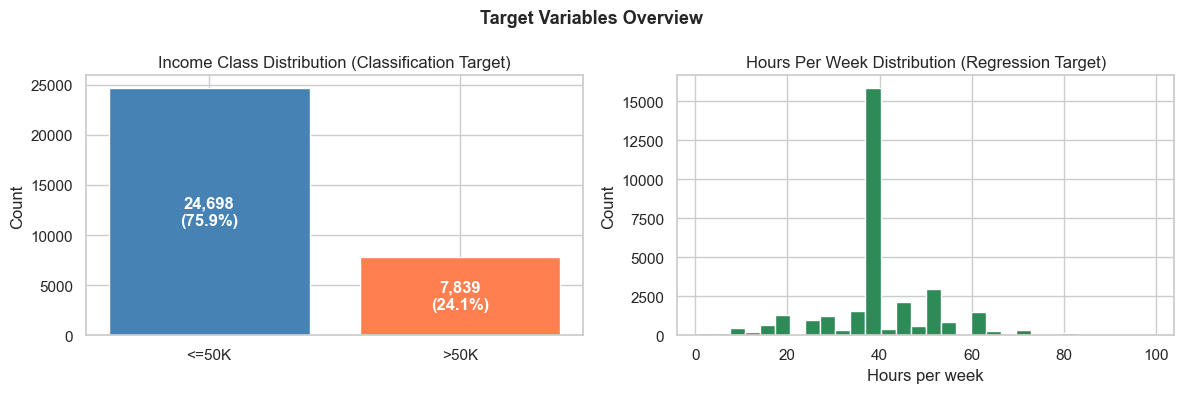

income
<=50K    24698
>50K      7839
Name: count, dtype: int64

hours-per-week:
count    32537.000000
mean        40.440329
std         12.346889
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64


In [13]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['income'].value_counts()
axes[0].bar(counts.index, counts.values, color=['steelblue', 'coral'])
axes[0].set_title('Income Class Distribution (Classification Target)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v / 2, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', va='center', color='white', fontweight='bold')

axes[1].hist(df['hours-per-week'], bins=30, color='seagreen', edgecolor='white')
axes[1].set_title('Hours Per Week Distribution (Regression Target)')
axes[1].set_xlabel('Hours per week')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variables Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_target_distributions.png', bbox_inches='tight')
plt.show()

print(df['income'].value_counts())
print(f"\nhours-per-week:\n{df['hours-per-week'].describe()}")

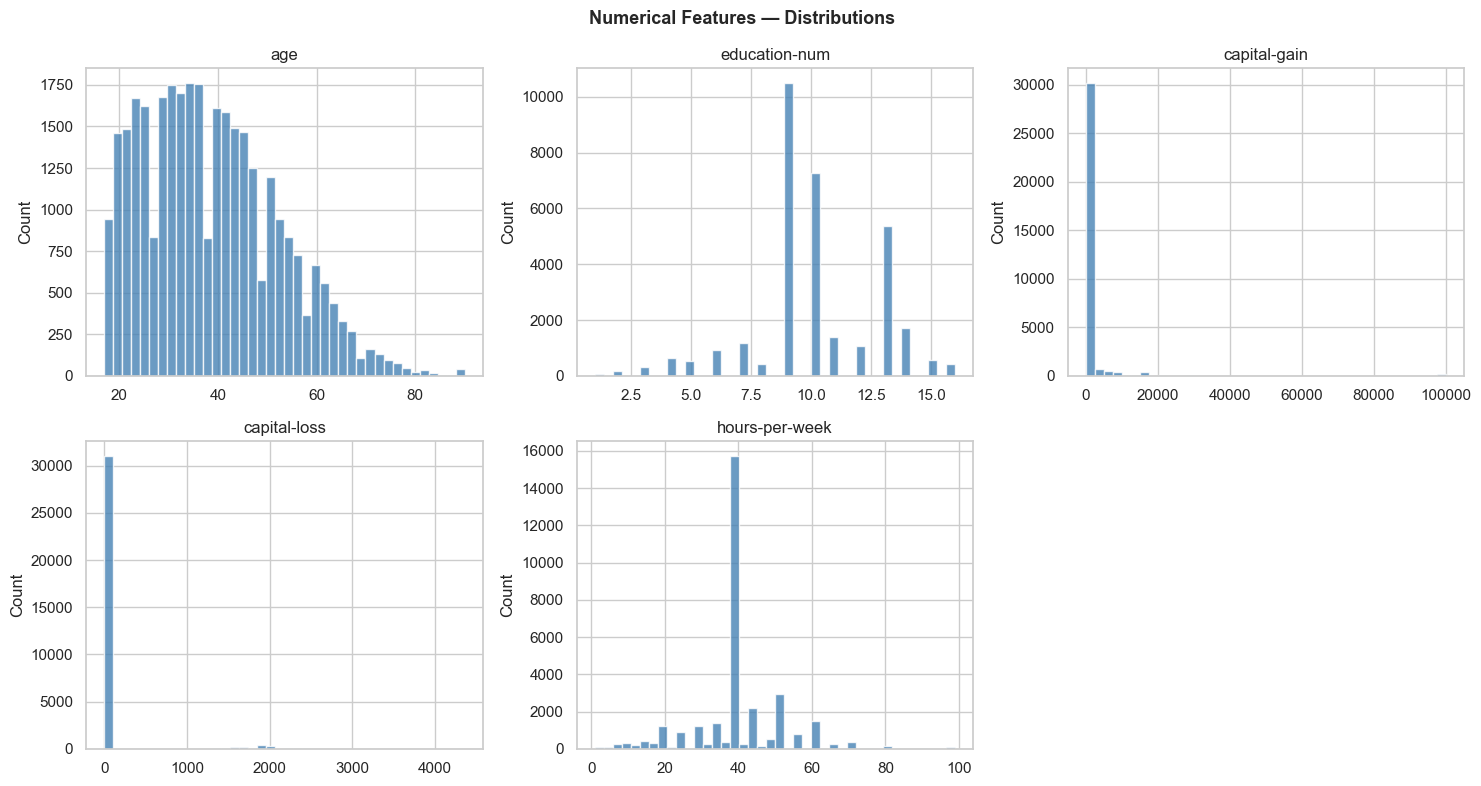

In [14]:
# Numerical features distribution
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

axes[-1].set_visible(False)
plt.suptitle('Numerical Features — Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_numerical_distributions.png', bbox_inches='tight')
plt.show()

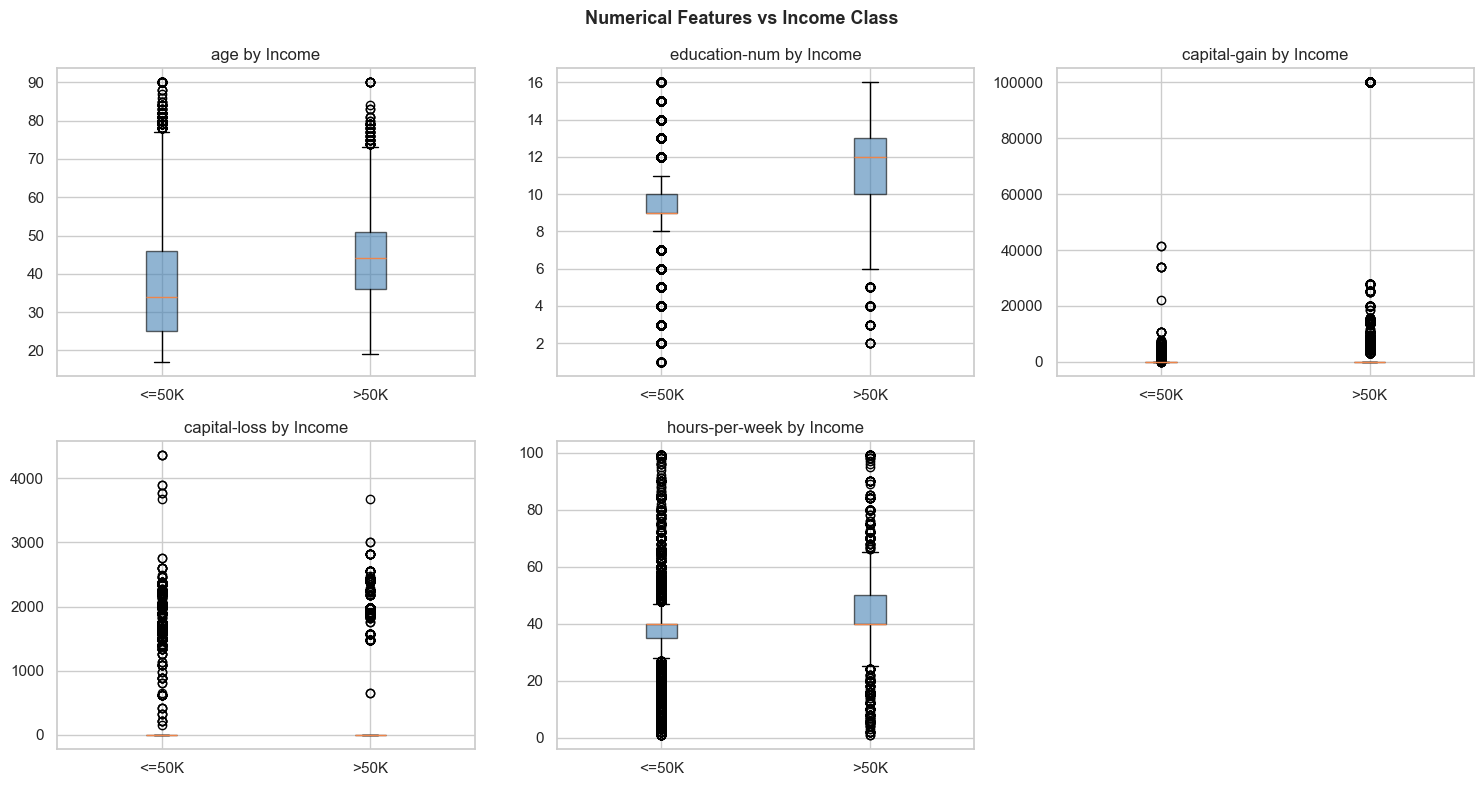

In [15]:
# Numerical features vs income (boxplots)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    groups = [df[df['income'] == cls][col].values for cls in ['<=50K', '>50K']]
    axes[i].boxplot(groups, labels=['<=50K', '>50K'], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col} by Income')

axes[-1].set_visible(False)
plt.suptitle('Numerical Features vs Income Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_boxplots_vs_income.png', bbox_inches='tight')
plt.show()

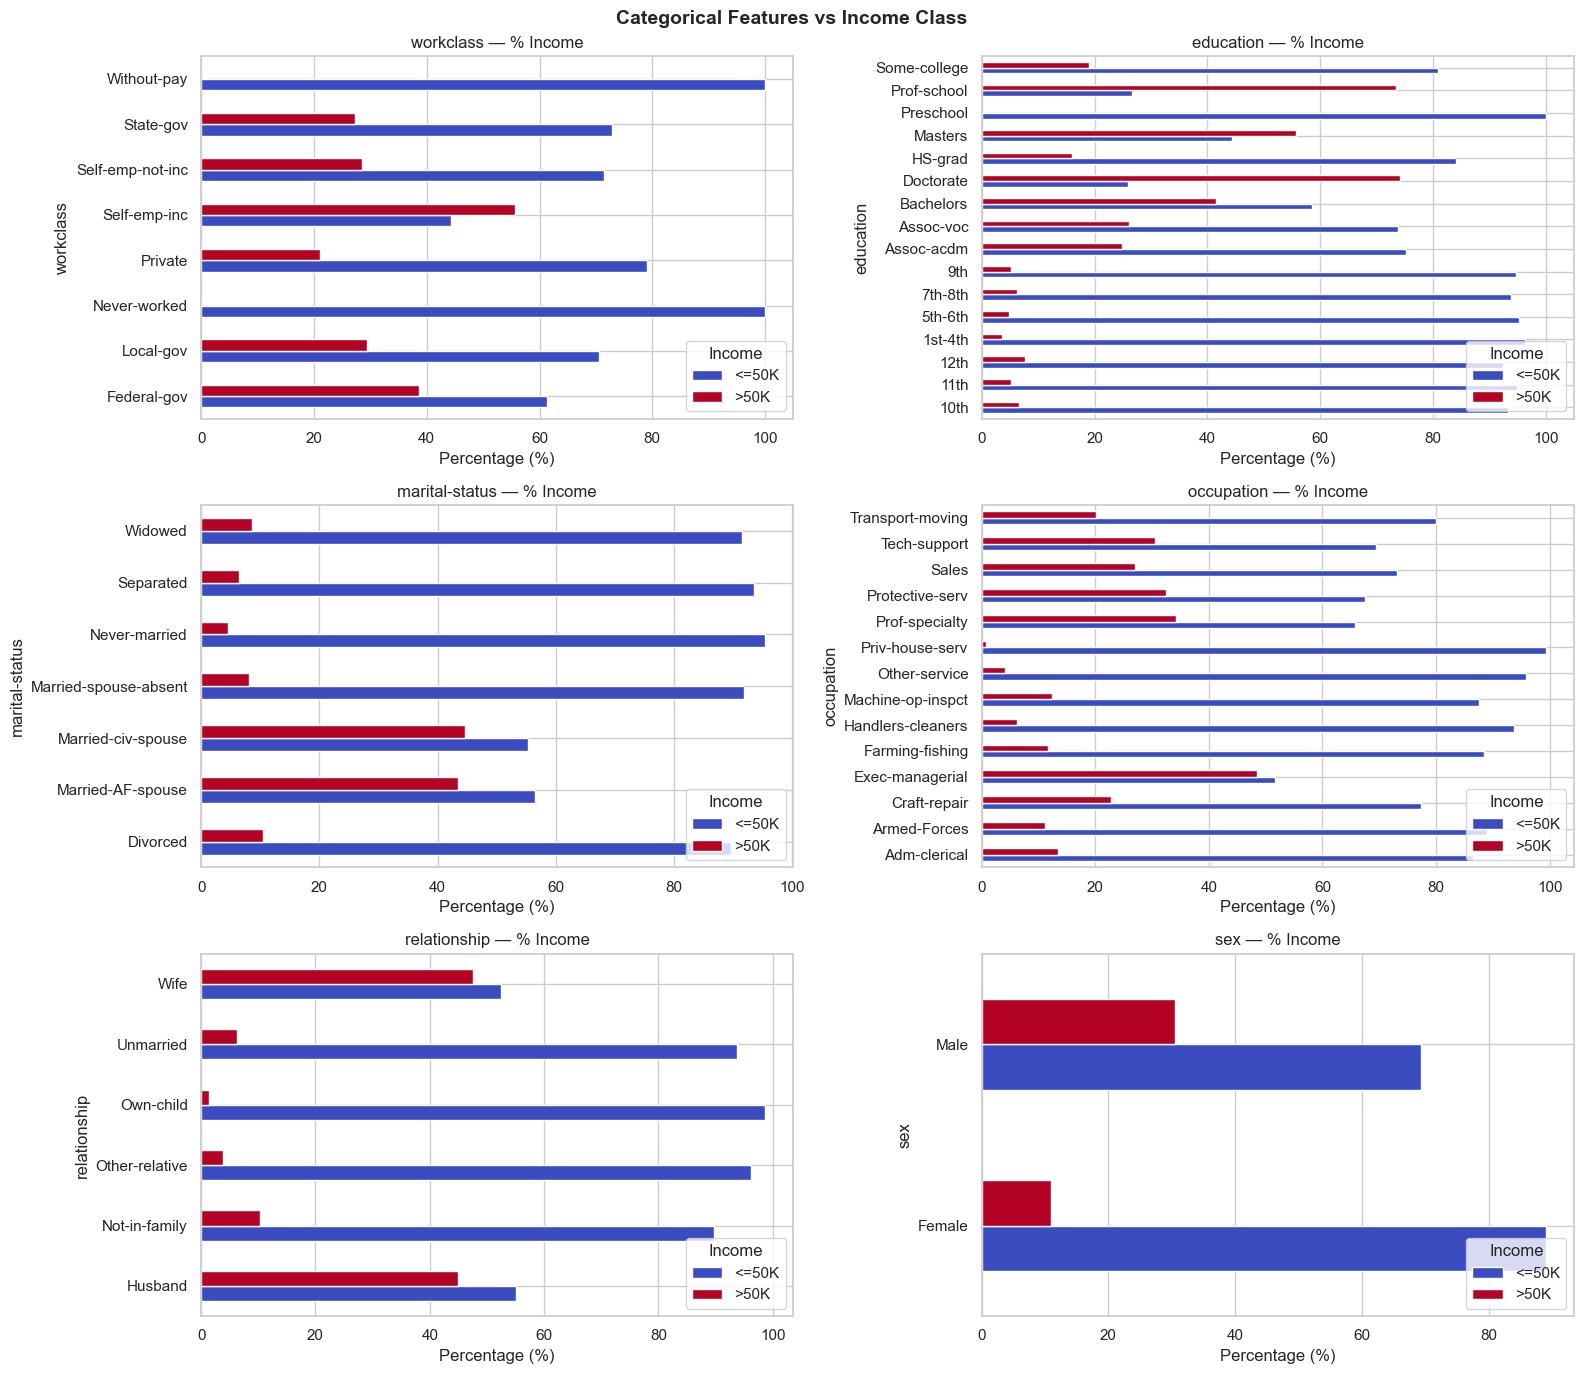

In [16]:
# Categorical features vs income
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'sex']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['income'], normalize='index') * 100
    ct.plot(kind='barh', ax=axes[i], colormap='coolwarm', edgecolor='white')
    axes[i].set_title(f'{col} — % Income')
    axes[i].set_xlabel('Percentage (%)')
    axes[i].legend(title='Income', loc='lower right')

plt.suptitle('Categorical Features vs Income Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_categorical_vs_income.png', bbox_inches='tight')
plt.show()

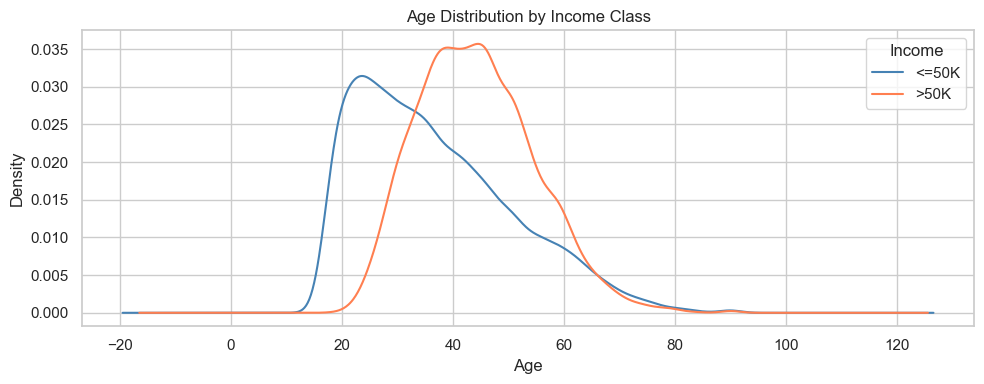

In [17]:
# Age distribution by income class (KDE)
fig, ax = plt.subplots(figsize=(10, 4))
for cls, color in zip(['<=50K', '>50K'], ['steelblue', 'coral']):
    df[df['income'] == cls]['age'].plot.kde(ax=ax, label=cls, color=color)
ax.set_title('Age Distribution by Income Class')
ax.set_xlabel('Age')
ax.legend(title='Income')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_age_by_income.png', bbox_inches='tight')
plt.show()

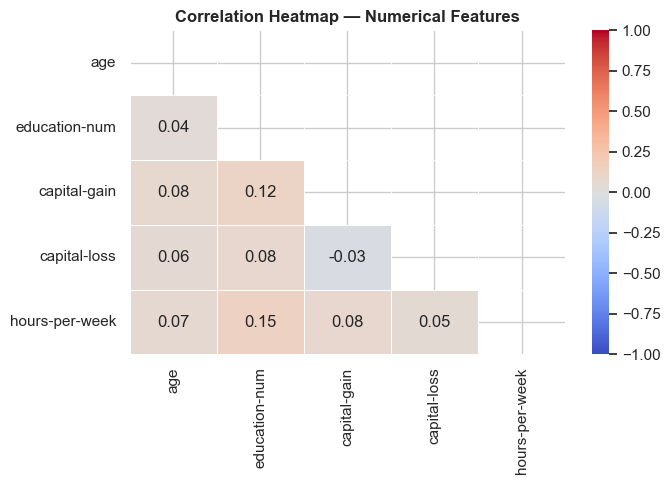

In [18]:
# Correlation heatmap — numerical features
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/07_correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
## 6. Export for D2

In [19]:
df_processed.to_csv('adult_processed.csv', index=False)

print('Saved: adult_processed.csv')
print(f'Shape: {df_processed.shape}')
print(f'\nFigures saved in {FIG_DIR}/:')
for f in sorted(os.listdir(FIG_DIR)):
    print(f'  {f}')

Saved: adult_processed.csv
Shape: (32537, 100)

Figures saved in figures_D1/:
  01_missing_values.png
  02_target_distributions.png
  03_numerical_distributions.png
  04_boxplots_vs_income.png
  05_categorical_vs_income.png
  06_age_by_income.png
  07_correlation_heatmap.png


---
## 7. Conclusions

### Dataset Summary
The Adult Income dataset contains **32,561 records** (32,537 after removing 24 duplicates) 
with 14 features and 1 target variable, covering demographic and employment characteristics. 
It was collected from the 1994 US Census and is widely used as a benchmark 
in the machine learning literature. Note: the full UCI release includes an additional 
test file (adult.test, ~16,000 records); this work uses only the training file (adult.data).

### Key Findings from EDA
- The dataset is **imbalanced**: ~76% earn <=50K and ~24% earn >50K. This will be considered in D2 by using F1 as the primary classification metric instead of accuracy.
- **Age and education-num** show a clear positive relationship with income.
- **Marital status** is one of the strongest categorical predictors — married individuals have a much higher proportion of >50K income.
- **Capital gain and capital loss** are highly skewed — most values are zero, with few large outliers.
- **Hours-per-week** is concentrated around 40 hours, making it a natural regression target.

### Data Cleaning Decisions
- Duplicate rows removed (minor effect on dataset size).
- Missing values in `workclass`, `occupation`, `native-country` imputed with **mode** — appropriate for categorical features with low missingness (<7%).
- `fnlwgt` dropped — census weight, not a personal characteristic.

### Data Preparation Decisions
- `capital_net` = capital-gain minus capital-loss — summarizes capital activity in one feature.
- `married` and `full_time` as binary flags — simplify complex categorical values into interpretable features.
- One-hot encoding for nominal categoricals; label encoding for binary (sex).